# Test File

## Decision Tree Regressor


Test 1: All Features:
Test MAE: 0.037
Test RMSE: 0.209
Test R2: 0.998
Train R2: 1.000


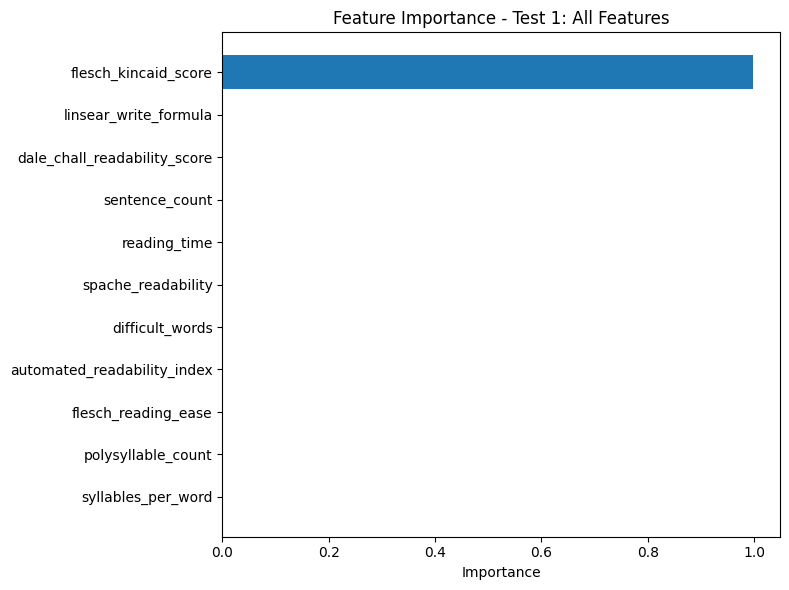


Test 2: No Flesch-Kincaid:
Test MAE: 0.294
Test RMSE: 0.567
Test R2: 0.985
Train R2: 1.000


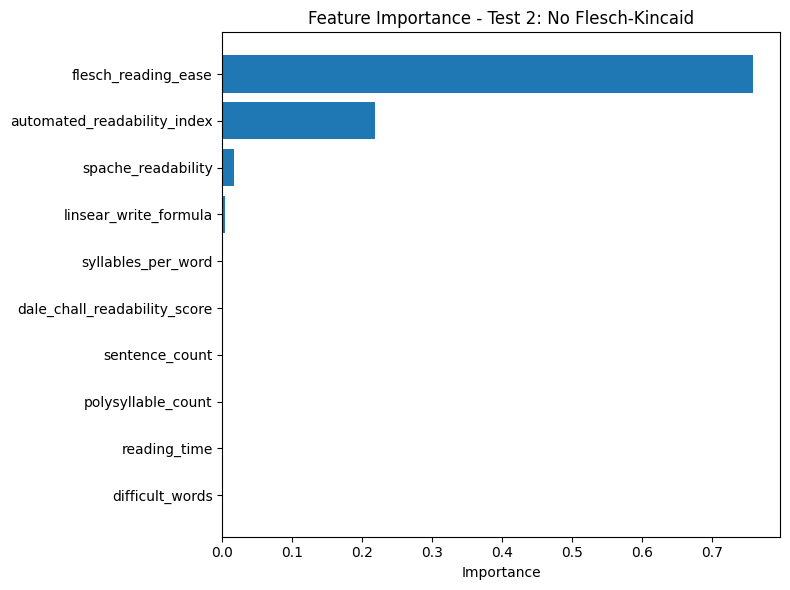


Test 3: Engineered Features:
Test MAE: 0.368
Test RMSE: 0.911
Test R2: 0.961
Train R2: 1.000


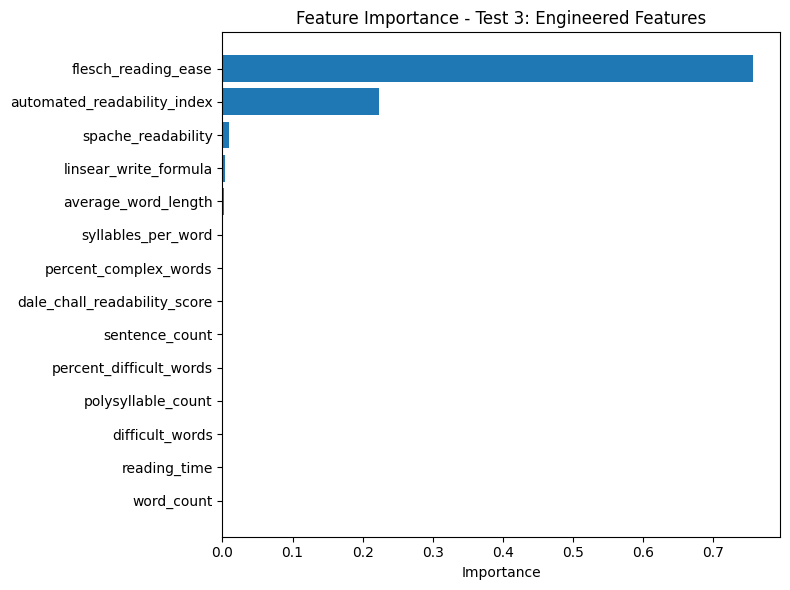


Decision Tree: No max_depth:
Test MAE: 0.368
Test RMSE: 0.911
Test R2: 0.961
Train R2: 1.000


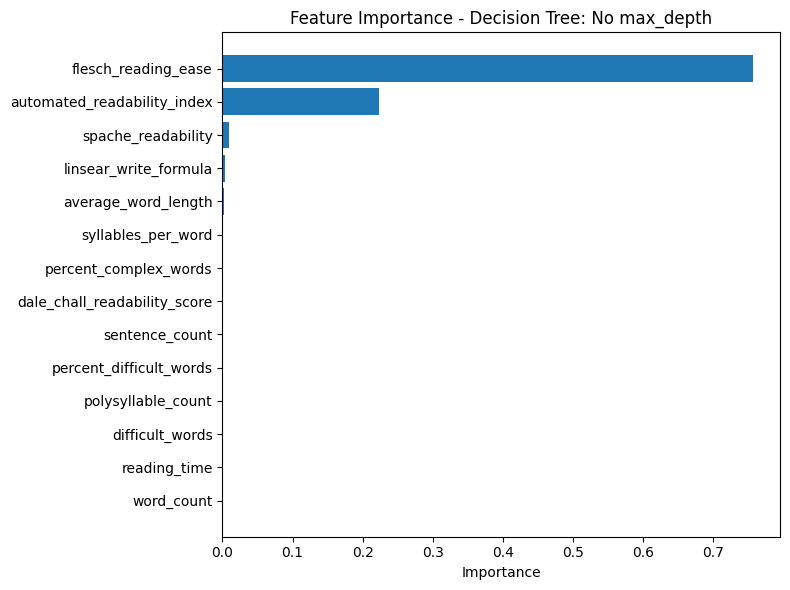


Decision Tree: max_depth=3:
Test MAE: 0.756
Test RMSE: 0.944
Test R2: 0.958
Train R2: 0.961


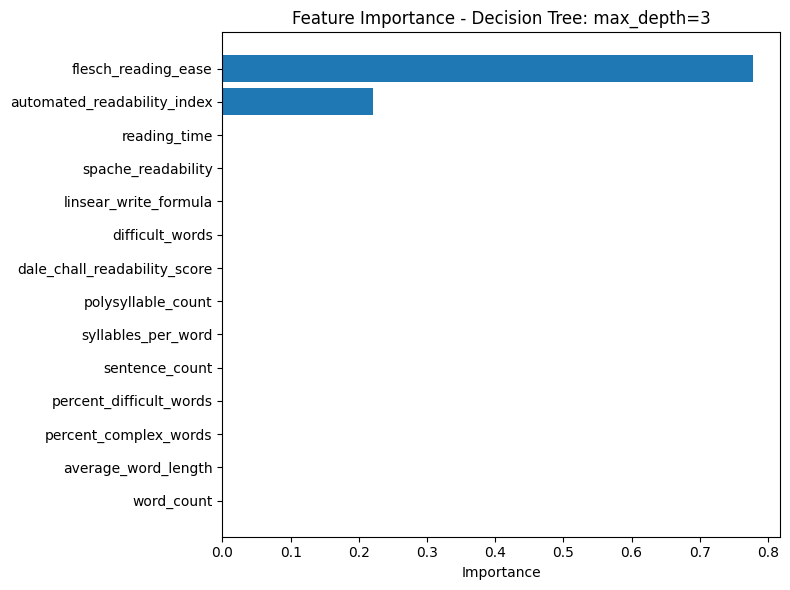


Decision Tree: max_depth=10:
Test MAE: 0.365
Test RMSE: 0.748
Test R2: 0.974
Train R2: 1.000


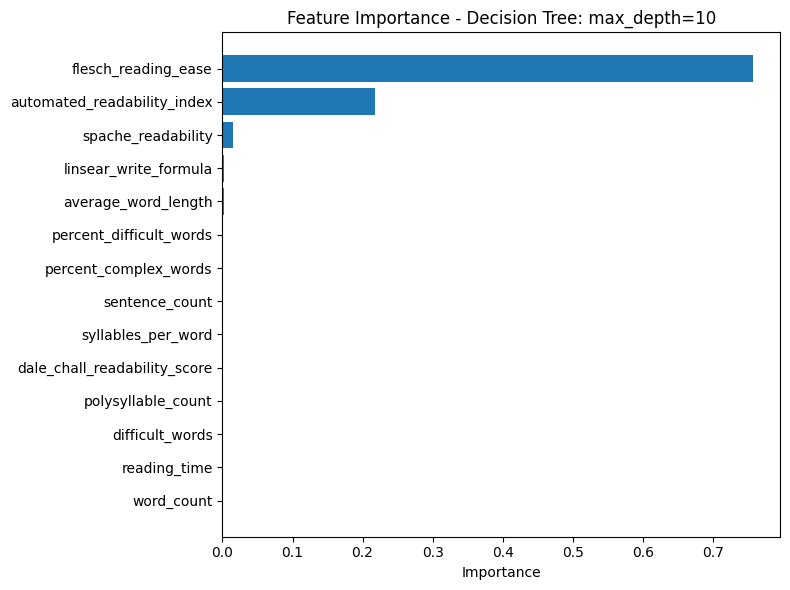

Best parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best cross-validated R^2: 0.9828540834791877

GridSearchCV Best Tree:
Test MAE: 0.334
Test RMSE: 0.621
Test R2: 0.982
Train R2: 0.996


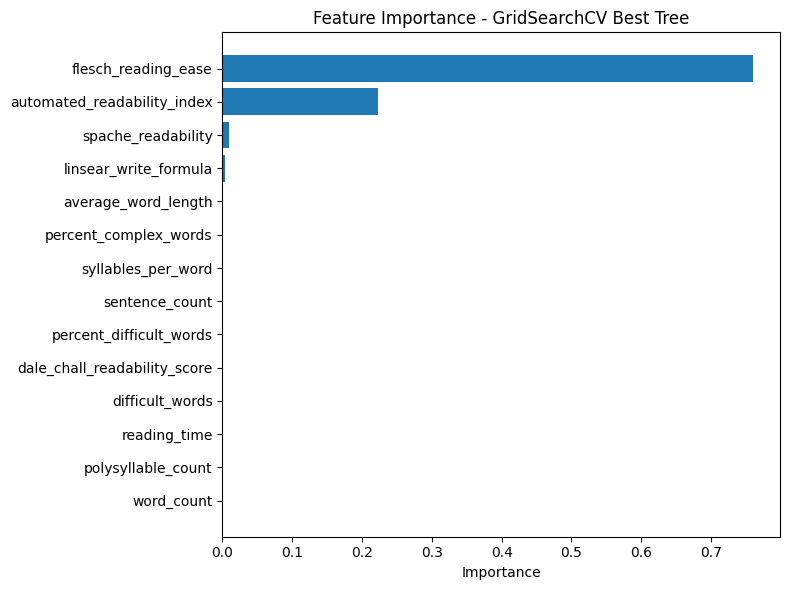

,Model,Features,Train MAE,Train RMSE,Train R2,Test MAE,Test RMSE,Test R2
0,Test 1: All Features,"flesch_kincaid_score, sentence_count, syllable...",0.000000,0.000000,1.000000,0.036789,0.208514,0.997969
1,Test 2: No Flesch-Kincaid,"sentence_count, syllables_per_word, polysyllab...",0.000000,0.000000,1.000000,0.294314,0.566631,0.984999
2,Test 3: Engineered Features,"word_count, average_word_length, percent_compl...",0.000000,0.000000,1.000000,0.367893,0.910731,0.961246
3,Decision Tree: No max_depth,"word_count, average_word_length, percent_compl...",0.000000,0.000000,1.000000,0.367893,0.910731,0.961246
4,Decision Tree: max_depth=3,"word_count, average_word_length, percent_compl...",0.672159,0.895731,0.961469,0.756414,0.944073,0.958357
5,Decision Tree: max_depth=10,"word_count, average_word_length, percent_compl...",0.016165,0.089904,0.999612,0.364966,0.748312,0.973836
6,GridSearchCV Best Tree,"word_count, average_word_length, percent_compl...",0.144663,0.300821,0.995654,0.334423,0.620690,0.982000


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../feature_engineering.csv')

def evaluate_tree_model(df, feature_columns, y_col, model_config, label, print_importance=False):
    X = df[feature_columns]
    y = df[y_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=456)
    
    model = DecisionTreeRegressor(**model_config, random_state=456)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)
    
    results = {
    'Model': label,
    'Features': ', '.join(feature_columns),
    'Train MAE': mean_absolute_error(y_train, y_train_pred),
    'Train RMSE': mean_squared_error(y_train, y_train_pred) ** 0.5,
    'Train R2': r2_score(y_train, y_train_pred),
    'Test MAE': mean_absolute_error(y_test, y_pred),
    'Test RMSE': mean_squared_error(y_test, y_pred) ** 0.5,
    'Test R2': r2_score(y_test, y_pred)
}

    
    print(f"\n{label}:")
    print(f"Test MAE: {results['Test MAE']:.3f}")
    print(f"Test RMSE: {results['Test RMSE']:.3f}")
    print(f"Test R2: {results['Test R2']:.3f}")
    print(f"Train R2: {results['Train R2']:.3f}")
    
    if print_importance:
        importances = model.feature_importances_
        indices = np.argsort(importances)
        plt.figure(figsize=(8, 6))
        plt.barh(np.array(feature_columns)[indices], importances[indices])
        plt.xlabel('Importance')
        plt.title(f'Feature Importance - {label}')
        plt.tight_layout()
        plt.show()
    
    return results, model

all_results = []

# Your main feature sets
feature_sets = [
    {
        'features': [
            'flesch_kincaid_score', 'sentence_count', 'syllables_per_word',
            'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
            'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
            'spache_readability', 'reading_time'
        ],
        'config': {},
        'label': 'Test 1: All Features'
    },
    {
        'features': [
            'sentence_count', 'syllables_per_word', 'polysyllable_count', 'flesch_reading_ease',
            'automated_readability_index', 'dale_chall_readability_score', 'difficult_words',
            'linsear_write_formula', 'spache_readability', 'reading_time'
        ],
        'config': {},
        'label': 'Test 2: No Flesch-Kincaid'
    },
    {
        'features': [
            'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words',
            'sentence_count', 'syllables_per_word', 'polysyllable_count', 'flesch_reading_ease',
            'automated_readability_index', 'dale_chall_readability_score', 'difficult_words',
            'linsear_write_formula', 'spache_readability', 'reading_time'
        ],
        'config': {},
        'label': 'Test 3: Engineered Features'
    }
]

# Evaluate each feature set
for test in feature_sets:
    res, model = evaluate_tree_model(
        df,
        test['features'],
        'fk_estimated_uk_age_num',
        test['config'],
        test['label'],
        print_importance=True
    )
    all_results.append(res)

# Engineered features for depth & grid search tests
engineered_features = feature_sets[2]['features']

# Decision tree, no max_depth
res, model_full = evaluate_tree_model(
    df, engineered_features, 'fk_estimated_uk_age_num', {}, "Decision Tree: No max_depth", print_importance=True
)
all_results.append(res)

# max_depth=3
res, model_d3 = evaluate_tree_model(
    df, engineered_features, 'fk_estimated_uk_age_num', {'max_depth': 3}, "Decision Tree: max_depth=3", print_importance=True
)
all_results.append(res)

# max_depth=10
res, model_d10 = evaluate_tree_model(
    df, engineered_features, 'fk_estimated_uk_age_num', {'max_depth': 10}, "Decision Tree: max_depth=10", print_importance=True
)
all_results.append(res)

# GridSearchCV
X = df[engineered_features]
y = df['fk_estimated_uk_age_num']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=456)
param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2'
)
grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validated R^2:", grid_search.best_score_)

res, model_grid = evaluate_tree_model(
    df, engineered_features, 'fk_estimated_uk_age_num', grid_search.best_params_, "GridSearchCV Best Tree", print_importance=True
)
all_results.append(res)

# Display all results together
results_df = pd.DataFrame(all_results)
display(results_df)
